# EDA — Predicción de ventas (Comercio de Horticultura)

Análisis exploratorio de datos usando la clase `AnalisisExploratorio` de `prediction_potTotal/eda.py`.

**Variable objetivo:** `PotTotal` (plantas en maceta) · **Horizonte:** 7 días

## 1. Configuración inicial e imports

In [1]:
import sys
sys.path.insert(0, '..')  # para que encuentre el paquete prediction_potTotal

from prediction_potTotal.eda import AnalisisExploratorio
from prediction_potTotal.dataset import DataLoader

print('Imports OK')

Imports OK


## 2. Cargar los datos

In [2]:
cargador = DataLoader()
analisis = AnalisisExploratorio()

df = cargador.cargar_datos()
df = cargador.crear_variable_objetivo_base(df)

columnas_clima = ['mean_temp', 'mean_humid', 'mean_prec_height_mm',
                  'total_prec_height_mm', 'mean_sun_dur_min', 'total_sun_dur_h']
columnas_venta = ['CutFlowers', 'PotOwn', 'PotPurchased', 'Wholesale', 'FruitsVegs', 'Commodity']

print('Dataset:', df.shape)

Dataset: (1359, 18)


## 3. Estructura y calidad de datos

In [3]:
analisis.resumen_general(df)

Dimensiones: 1359 filas x 18 columnas
Fecha mínima: 2016-12-12
Fecha máxima: 2020-08-31


In [4]:
dias_faltantes = analisis.verificar_continuidad_temporal(df)

Días esperados en el rango: 1359
Días faltantes en la serie: 0


In [5]:
analisis.resumen_nulos(df)

                      nulos  porcentaje_%
total_sun_dur_h           5          0.37
mean_sun_dur_min          5          0.37
mean_temp                 4          0.29
mean_prec_height_mm       4          0.29
mean_humid                4          0.29
mean_prec_flag            4          0.29
total_prec_height_mm      4          0.29


,nulos,porcentaje_%
total_sun_dur_h,5,0.37
mean_sun_dur_min,5,0.37
mean_temp,4,0.29
mean_prec_height_mm,4,0.29
mean_humid,4,0.29
mean_prec_flag,4,0.29
total_prec_height_mm,4,0.29


In [6]:
analisis.detectar_duplicados(df)

Filas totalmente duplicadas: 0
Fechas duplicadas: 0


In [7]:
analisis.detectar_valores_negativos(df, columnas_venta)

Valores negativos por columna de venta: {'CutFlowers': 0, 'PotOwn': 0, 'PotPurchased': 0, 'Wholesale': 0, 'FruitsVegs': 0, 'Commodity': 0}


{'CutFlowers': 0,
 'PotOwn': 0,
 'PotPurchased': 0,
 'Wholesale': 0,
 'FruitsVegs': 0,
 'Commodity': 0}

In [8]:
analisis.resumen_estadistico(df, columnas_venta + ['PotTotal'])

       CutFlowers   PotOwn  PotPurchased  Wholesale  FruitsVegs  Commodity  \
count     1359.00  1359.00       1359.00    1359.00     1359.00    1359.00   
mean       244.00   144.25         45.30      45.23       15.01      84.35   
std        244.74   248.19         54.20     132.63       15.23     146.43   
min          0.00     0.00          0.00       0.00        0.00       0.00   
25%        115.20     0.00          3.50       0.00        2.92      19.54   
50%        202.00    38.50         30.10       0.00       11.55      60.65   
75%        306.23   171.75         63.95       0.00       22.56     108.19   
max       2346.45  1871.00        457.50    1457.11      157.70    2113.80   

       PotTotal  
count   1359.00  
mean     189.55  
std      267.04  
min        0.00  
25%       22.20  
50%       99.40  
75%      234.80  
max     1926.40  


,CutFlowers,PotOwn,PotPurchased,Wholesale,FruitsVegs,Commodity,PotTotal
count,1359.00,1359.00,1359.00,1359.00,1359.00,1359.00,1359.00
mean,244.00,144.25,45.30,45.23,15.01,84.35,189.55
std,244.74,248.19,54.20,132.63,15.23,146.43,267.04
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,115.20,0.00,3.50,0.00,2.92,19.54,22.20
50%,202.00,38.50,30.10,0.00,11.55,60.65,99.40
75%,306.23,171.75,63.95,0.00,22.56,108.19,234.80
max,2346.45,1871.00,457.50,1457.11,157.70,2113.80,1926.40


## 4. Preparar variables auxiliares para el resto del EDA

In [9]:
df['weekday'] = df['Date'].dt.day_name()
df['month'] = df['Date'].dt.month
df['is_holiday'] = df['public_holiday'] != 'no'

## 5. Variable objetivo: `PotTotal`

In [10]:
analisis.analizar_pot_total(df)

count    1359.00
mean      189.55
std       267.04
min         0.00
25%        22.20
50%        99.40
75%       234.80
max      1926.40
Name: PotTotal, dtype: float64
Asimetría (skewness): 2.70
Curtosis: 9.07
Días con venta = 0: 247 (18.2%)


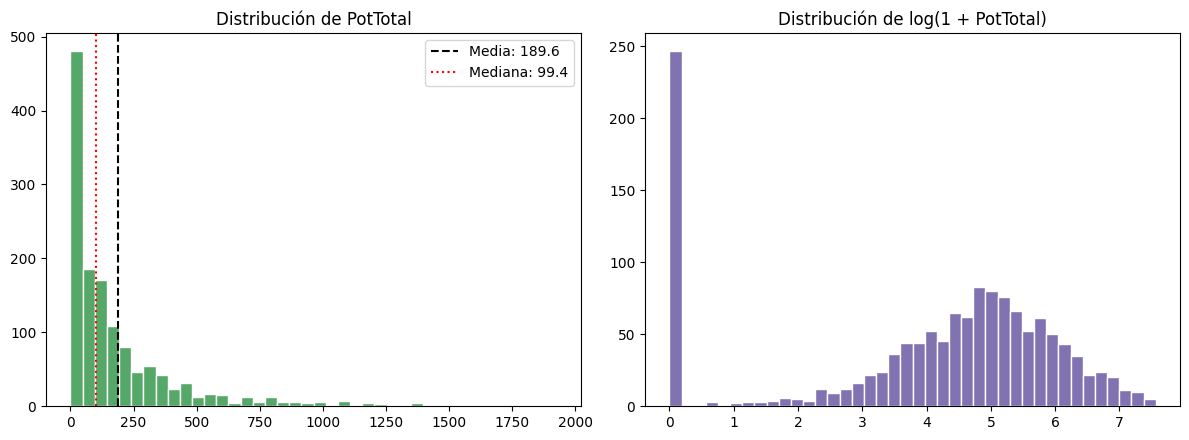

In [11]:
analisis.graficar_distribucion_pot_total(df)

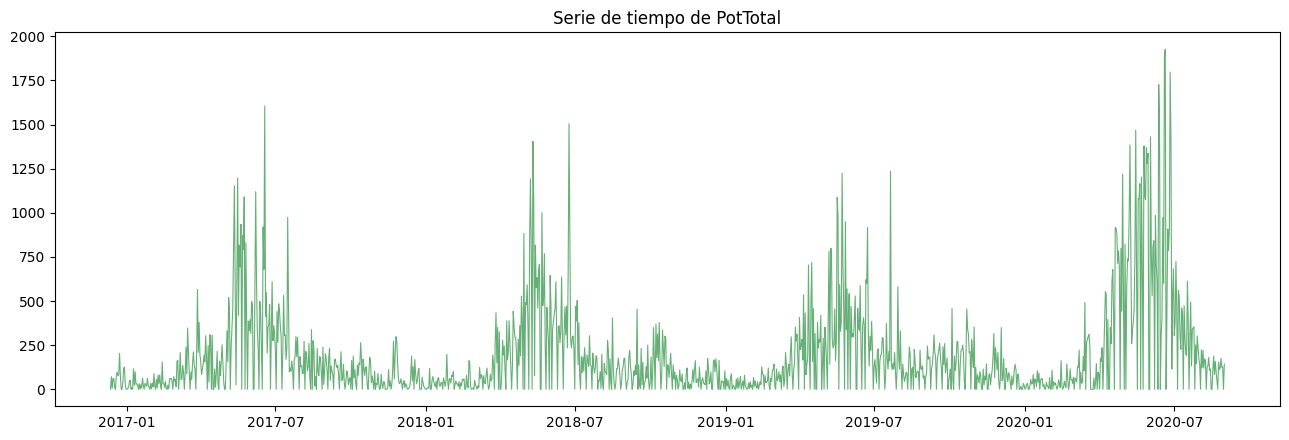

In [12]:
analisis.graficar_serie_tiempo(df, 'PotTotal')

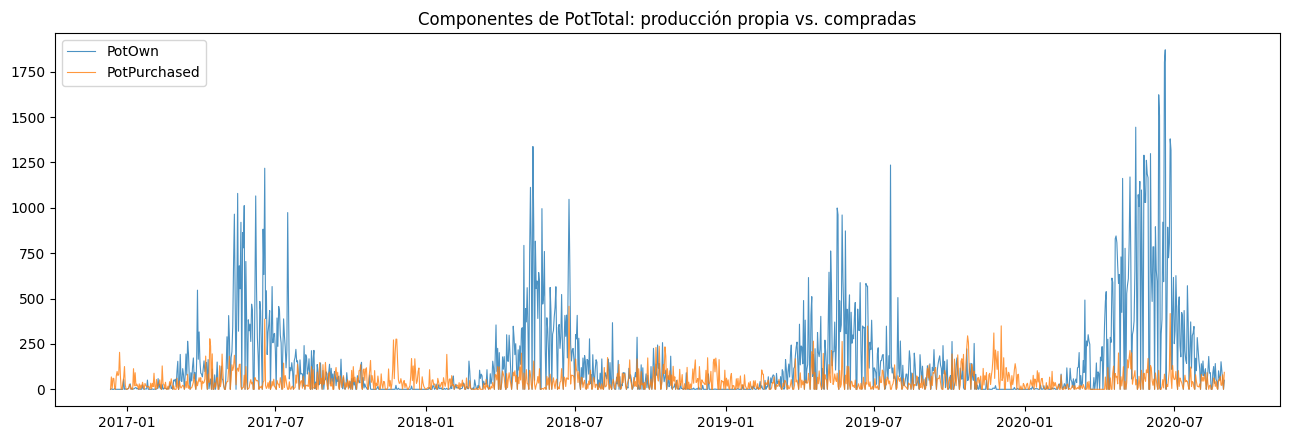

In [13]:
analisis.graficar_componentes_pot_total(df)

## 6. Variables climáticas

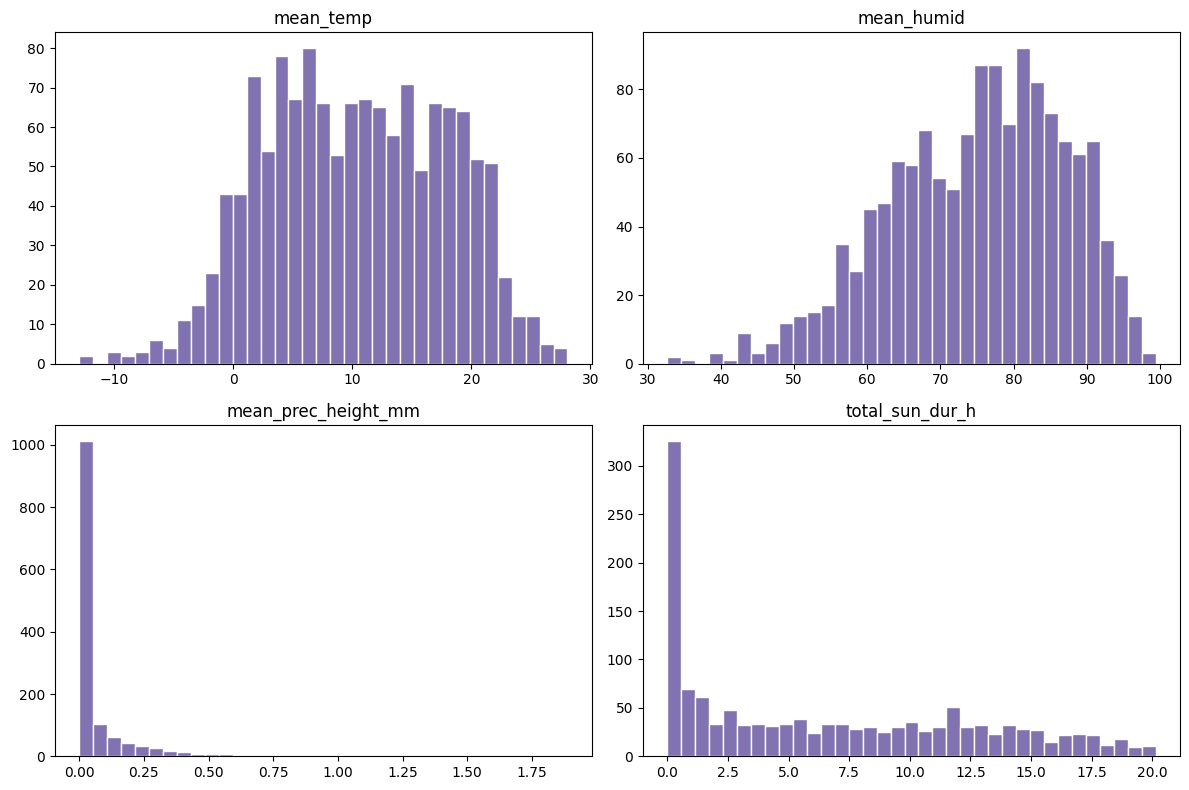

In [14]:
analisis.graficar_distribucion_clima(df, ['mean_temp', 'mean_humid', 'mean_prec_height_mm', 'total_sun_dur_h'])

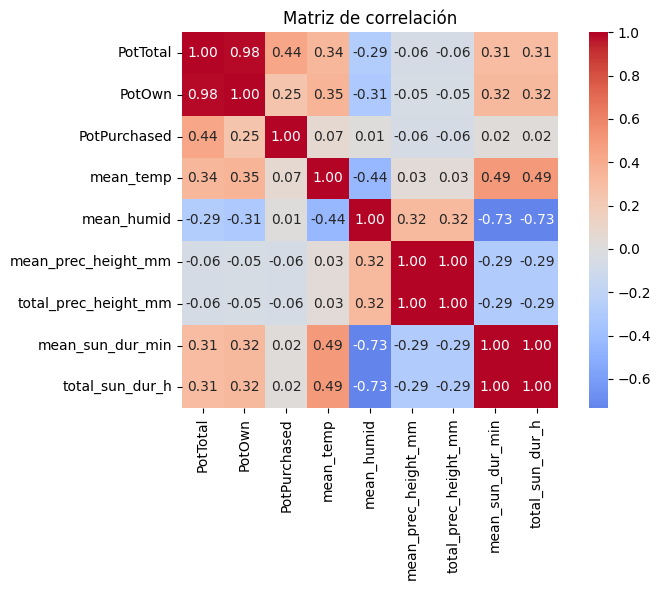

In [15]:
columnas_corr = ['PotTotal', 'PotOwn', 'PotPurchased'] + columnas_clima
analisis.graficar_matriz_correlacion(df, columnas_corr)

## 7. Calendario y estacionalidad

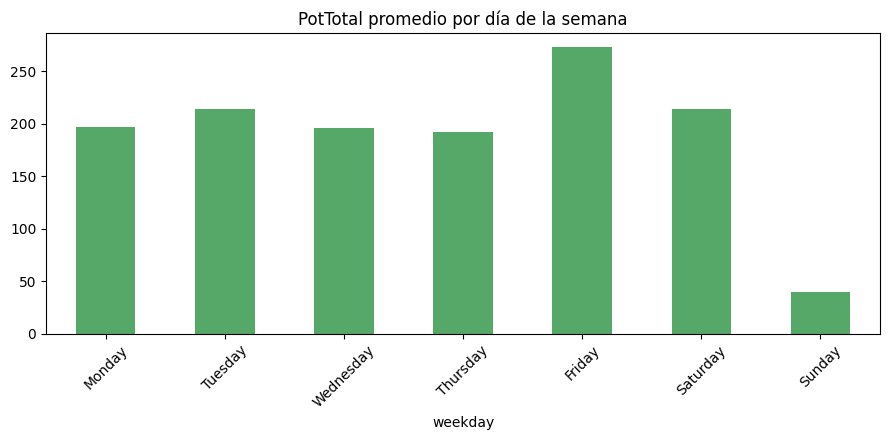

,PotTotal
weekday,
Monday,197.0
Tuesday,214.6
Wednesday,196.4
Thursday,191.8
Friday,273.0
Saturday,213.9
Sunday,40.1


In [16]:
analisis.graficar_ventas_por_dia_semana(df)

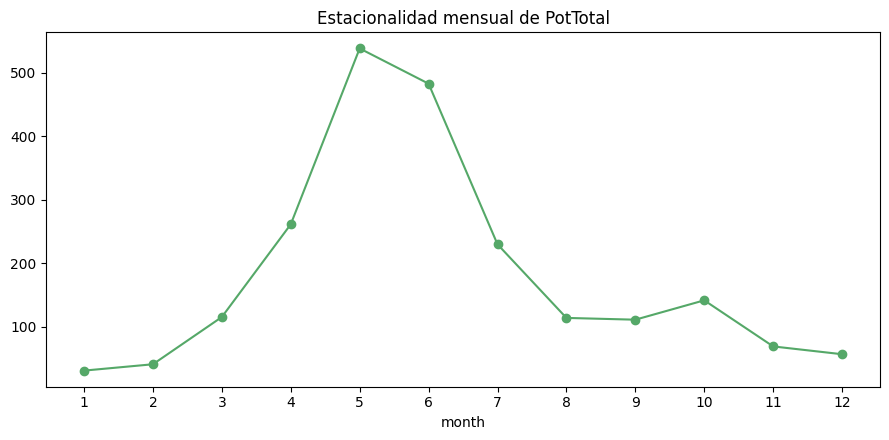

,PotTotal
month,
1,31.2
2,41.2
3,115.6
4,261.6
5,538.6
6,483.1
7,230.1
8,114.2
9,111.4


In [17]:
analisis.graficar_estacionalidad_mensual(df)

## 8. Outliers e inflación de ceros

In [18]:
analisis.detectar_outliers_iqr(df, 'PotTotal')

{'Q1': 22.2, 'Q3': 234.8, 'IQR': 212.6, 'limite_inferior': -296.7, 'limite_superior': 553.7, 'n_outliers': 112, 'pct_outliers': np.float64(8.24)}


{'Q1': 22.2,
 'Q3': 234.8,
 'IQR': 212.6,
 'limite_inferior': -296.7,
 'limite_superior': 553.7,
 'n_outliers': 112,
 'pct_outliers': np.float64(8.24)}

In [19]:
analisis.analizar_inflacion_ceros(df)

Días con PotTotal = 0: 18.2%
De esos días, 73% son domingos.


## 9. Hallazgos y conclusiones del EDA

_(completa aquí tus propias observaciones, en tus palabras, para la sección 7.2 de tu monografía)_

- ...
- ...
- ...